In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Read data
# -----------------------
df = pd.read_csv("master_costs.csv")

methods = df["Method"].values
cTotal = df["cTotal"].values
cFix = df["cFix"].values
cNetwork = df["cNetwork"].values

x = np.arange(len(methods))

# -----------------------
# Plot 1: Total Costs (stacked)
# -----------------------
plt.figure()



<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

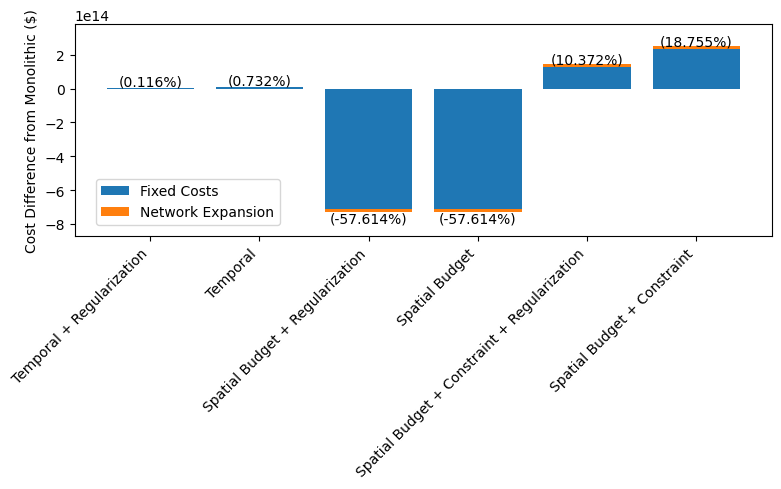

In [29]:
# -----------------------
# Plot 2: Differences from Monolithic (with padding)
# -----------------------
baseline_total = cTotal[0]
baseline_fix = cFix[0]
baseline_network = cNetwork[0]

diff_fix = cFix[1:] - baseline_fix
diff_network = cNetwork[1:] - baseline_network
diff_total = cTotal[1:] - baseline_total
percent_error = diff_total / baseline_total * 100

labels = methods[1:]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))  # <-- makes plot bigger overall

plt.bar(x, diff_fix, label="Fixed Costs")
plt.bar(x, diff_network, bottom=diff_fix, label="Network Expansion")

# Annotate percent error
for i in range(len(diff_total)):
    plt.text(
        x[i],
        diff_total[i],
        f"({percent_error[i]:.3f}%)",
        ha="center",
        va="bottom" if diff_total[i] >= 0 else "top"
    )

# --- Add vertical padding ---
y_min = min(0, diff_total.min())
y_max = max(0, diff_total.max())

padding = 0.15 * (y_max - y_min)
plt.ylim(y_min - padding, y_max + padding)

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Cost Difference from Monolithic ($)")
#plt.title("Cost Differences Relative to Monolithic Model")
plt.legend(loc="lower left", bbox_to_anchor=(0.02, 0.02))

plt.tight_layout()
plt.savefig("cost_differences.png")



Network

[ 2.38634532e-04  2.38634532e-04  2.38634532e-04  2.38634532e-04
 -3.09432314e+01 -3.09432314e+01]


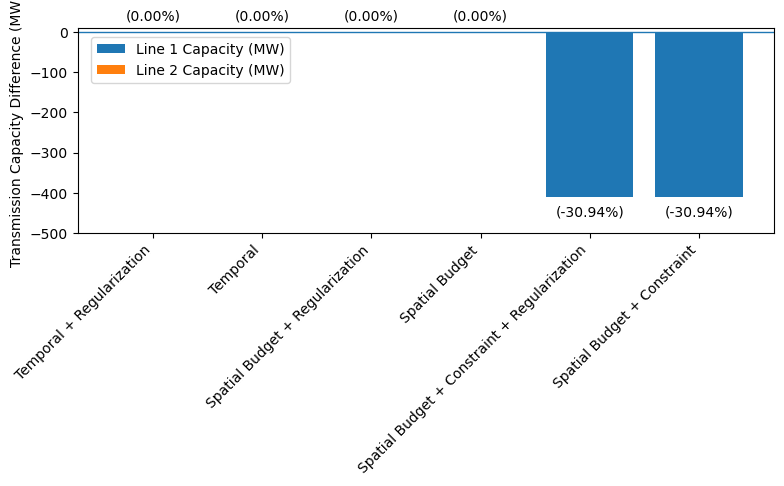

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Read data
# -----------------------
df = pd.read_csv("master_network_expansion.csv")
for col in ["Line 1", "Line 2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=["Line 1", "Line 2"])

methods = df["Method"].values
line1 = df["Line 1"].values
line2 = df["Line 2"].values

total_capacity = line1 + line2

# -----------------------
# Baseline (Monolithic)
# -----------------------
baseline_total = total_capacity[0]
baseline_line1 = line1[0]
baseline_line2 = line2[0]

# Differences (exclude monolithic)
diff_line1 = line1[1:] - baseline_line1
diff_line2 = line2[1:] - baseline_line2
diff_total = total_capacity[1:] - baseline_total

percent_error = 100 * diff_total / baseline_total

labels = methods[1:]
x = np.arange(len(labels))
print(percent_error)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8, 5))

plt.bar(x, diff_line1, label="Line 1 Capacity (MW)")
plt.bar(x, diff_line2, bottom=diff_line1, label="Line 2 Capacity (MW)")

# Zero line
plt.axhline(0, linewidth=1)

# -----------------------
# Annotations (percent change)
# -----------------------
y_extent = max(abs(diff_total.min()), abs(diff_total.max()))
offset = 0.05 * y_extent

for i in range(len(diff_total)):
    plt.text(
        x[i],
        diff_total[i] + (offset if diff_total[i] >= 0 else -offset),
        f"({percent_error[i]:.2f}%)",
        ha="center",
        va="bottom" if diff_total[i] >= 0 else "top"
    )

# -----------------------
# Axes & layout
# -----------------------
plt.ylim(-500, 10)
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Transmission Capacity Difference (MW)")
plt.legend(loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout()
plt.savefig("transmission_capacity_differences.png", dpi=300)
plt.show()


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Read data
# -----------------------
df = pd.read_csv("master_network_expansion.csv")

# Identify transmission line columns (named "1", "2", ..., "120")
line_cols = [c for c in df.columns if c.isdigit()]

# Ensure numeric
df[line_cols] = df[line_cols].apply(pd.to_numeric, errors="coerce")

# Drop rows with missing data
df = df.dropna(subset=line_cols)

methods = df["Method"].values

# -----------------------
# Baseline (Monolithic)
# -----------------------
baseline = df.iloc[0][line_cols]  # Series indexed by line

# -----------------------
# Filter negligible baseline lines
# (keep lines with >= 100 MW in monolithic)
# -----------------------
keep_lines = baseline[baseline >= 100].index

# -----------------------
# Differences relative to monolithic
# -----------------------
diff = (
    df.loc[1:, keep_lines]
    .subtract(baseline[keep_lines], axis=1)
)

# diff shape:
# rows   -> scenarios (excluding monolithic)
# columns-> transmission lines

# -----------------------
# Percent difference (total, for annotation)
# -----------------------
baseline_total = baseline[keep_lines].sum()
diff_total = diff.sum(axis=1)
percent_error = 100 * diff_total / baseline_total

diff_total /= 1000
diff_total


1    -377.209764
2    -350.992953
3   -8320.030807
4   -8320.030807
5   -8320.030807
6   -8320.030807
dtype: object

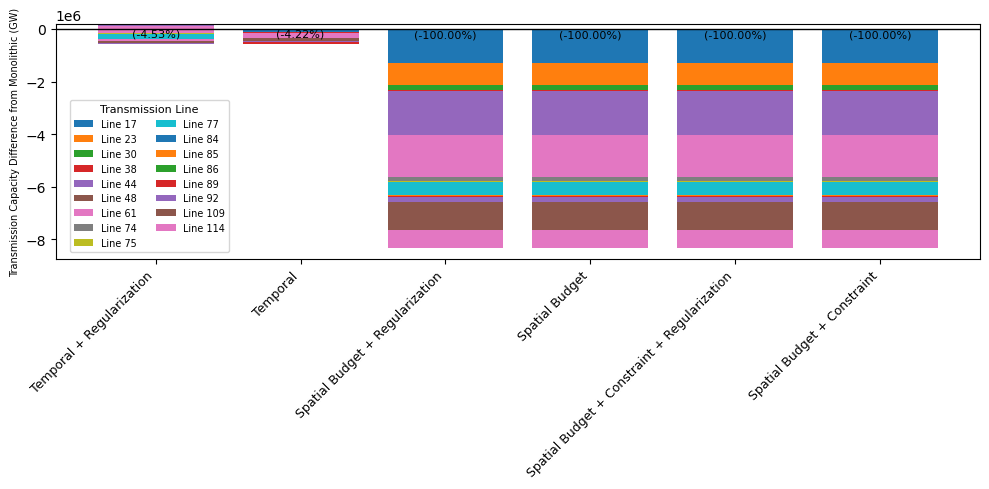

In [53]:
# Ensure numeric
diff = diff.astype(float)

x = np.arange(len(diff.index))
bottom = np.zeros(len(diff), dtype=float)

plt.figure(figsize=(10, 5))

for col in diff.columns:
    vals = diff[col].values.astype(float)
    plt.bar(
        x,
        vals,
        bottom=bottom,
        label=f"Line {col}"
    )
    bottom += vals

# Zero line
plt.axhline(0, linewidth=1, color="black")

# Percent annotations
y_extent = max(abs(diff_total.min()), abs(diff_total.max()))
offset = 0.05 * y_extent

for i, val in enumerate(diff_total):
    plt.text(
        x[i],
        val + (offset if val >= 0 else -offset),
        f"({percent_error.iloc[i]:.2f}%)",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontsize=8
    )

# X-axis labels
plt.xticks(
    x,
    methods[1:],
    rotation=45,
    ha="right",
    fontsize=9
)
plt.ylabel("Transmission Capacity Difference from Monolithic (GW)", fontsize=7)
#plt.title("Transmission Capacity Differences by Line")

plt.legend(
    title="Transmission Line",
    loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    fontsize=7,
    title_fontsize=8,
    ncol=2
)


plt.tight_layout()
#
#plt.subplots_adjust(right=0.78)
plt.savefig("rts_transmission_difference.png")


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("master_capacity.csv")


In [32]:
cap_cols = [f"EndCap{i}" for i in range(1, 8)]
cap_by_fuel = df.groupby("fuel")[cap_cols].sum()
cap_diff = pd.DataFrame(
    {
        f"Scenario {i}": cap_by_fuel[f"EndCap{i}"] - cap_by_fuel["EndCap1"]
        for i in range(2, 8)
    }
)


tol = 1e-6

for df_diff in [cap_diff]:
    df_diff.drop(index="total", errors="ignore", inplace=True)
    df_diff[:] = df_diff.where(df_diff.abs() > tol, 0)

cap_diff = cap_diff.loc[(cap_diff != 0).any(axis=1)]
cap_diff /= 1000000
cap_diff

,Scenario 2,Scenario 3,Scenario 4,Scenario 5,Scenario 6,Scenario 7
fuel,,,,,,
ngcc new,-3.333889e+00,-1.163889e+00,-3.333889e+00,-3.333889e+00,-2.836842,-3.333889
ngct new,3.356064e+00,1.256064e+00,-3.333936e+00,-3.333936e+00,-2.895409,-1.953354
ngst new,-5.637150e-05,-5.637150e-05,-5.637150e-05,-5.637150e-05,-0.000056,-0.000056
nuclear new,-5.335982e-06,-5.335982e-06,-5.335982e-06,-5.335982e-06,0.313889,0.343668
solar new,-9.149760e-07,-9.149760e-07,-9.149760e-07,-9.149760e-07,1.127255,1.199065
wind new,-5.781912e-06,-5.781912e-06,-5.781912e-06,-5.781912e-06,0.682744,0.751769


In [33]:
scenario_label_map = {
    "Scenario 2": "Temporal + Regularization",
    "Scenario 3": "Temporal",
    "Scenario 4": "Spatial Budget + Regularization",
    "Scenario 5": "Spatial Budget",
    "Scenario 6": "Spatial Budget + Constraint + Regularization",
    "Scenario 7": "Spatial Budget + Constraint"
}

cap_diff.rename(columns=scenario_label_map, inplace=True)

scenario_order = [
    "Temporal + Regularization",
    "Temporal",
    "Spatial Budget + Regularization",
    "Spatial Budget",
    "Spatial Budget + Constraint + Regularization",
    "Spatial Budget + Constraint"
]

cap_diff = cap_diff[scenario_order]


/var/folders/8c/wk0kq3816vzfxn6xszb8zbrh0000gr/T/ipykernel_28034/3982218770.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cap_diff.rename(columns=scenario_label_map, inplace=True)


In [34]:
fuel_label_map = {
    "ngcc new": "New NGCC",
    "ngct new": "New NGCT",
    "ngst new": "New NGST",
    "nuclear new": "New Nuclear",
    "solar new": "New Solar",
    "wind new": "New Wind"
}

cap_diff.rename(index=fuel_label_map, inplace=True)

fuel_order = [
    "New NGCC",
    "New NGCT",
    "New NGST",
    "New Nuclear",
    "New Solar",
    "New Wind",
]

fuel_color_map = {
    "New NGCT": "#C34C4C",
    "New NGCC": "#BE83046F",
    "New Nuclear": "#D28C00",
    "New NGST": "#8D27C4",
    "New Solar": "#9D9F49",
    "New Wind": "#027450",
}


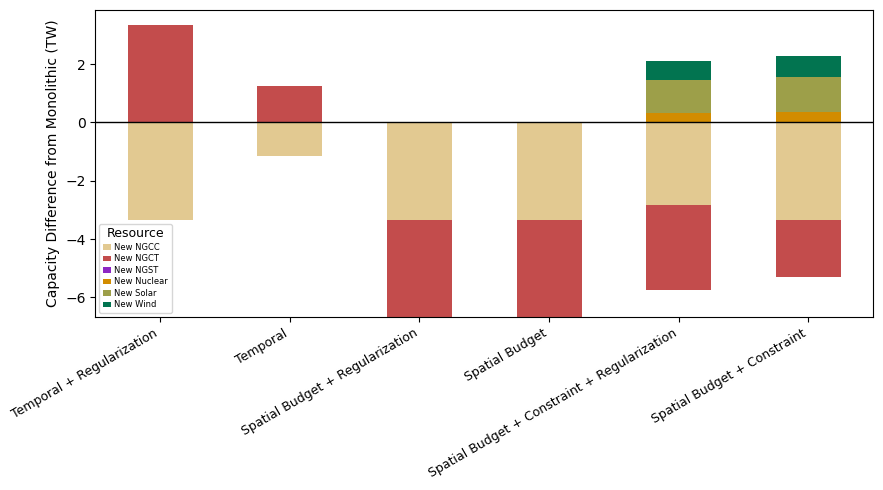

In [35]:
cap_diff_plot = cap_diff.T
colors = [fuel_color_map.get(fuel, "#999999") for fuel in cap_diff_plot.columns]

plt.figure(figsize=(9, 5))

cap_diff_plot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=plt.gca()
)

plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Capacity Difference from Monolithic (TW)")
#plt.title("Generation Capacity Differences")
plt.xticks(
    rotation=30,      # slant labels
    ha="right",       # align nicely with ticks
    fontsize=9        # smaller text
)
plt.legend(
    title="Resource",
    loc="lower left",          # position in the axes
    #bbox_to_anchor=(0.01, 0.99),  # slightly inset from top-left
    fontsize=6,                # legend text size
    title_fontsize=9,          # legend title size
    labelspacing=0.3,          # vertical spacing between entries
    handlelength=1.0,          # length of the color boxes
    handletextpad=0.4          # space between box and text
)

plt.tight_layout()
plt.savefig("capacity_diff.png")